# Simulation CSV Plots

Set `CSV_PATH` below if you want a specific run. Leave it as `None` to use the newest `data/run_*.csv` file.

In [20]:
# Uncomment this if your notebook kernel does not have the plotting packages:
# %pip install pandas matplotlib

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "misc":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Set this to a specific file if needed, for example:
# CSV_PATH = PROJECT_ROOT / "data" / "run_2026-06-07T19-54-22.csv"
CSV_PATH = None

if CSV_PATH is None:
    run_files = sorted((PROJECT_ROOT / "data").glob("run_*.csv"), key=lambda path: path.stat().st_mtime)
    if not run_files:
        raise FileNotFoundError("No data/run_*.csv files found")
    CSV_PATH = run_files[-1]

df = pd.read_csv(CSV_PATH)
df.head()

,epoch,population,food,bushes,avg_speed,avg_vision,avg_reproduction,max_generation,oldest_age,births,deaths,food_eaten
0,1,20,13,15,50.0,100.0,500.0,0,0.50,0,0,2
1,2,20,10,15,50.0,100.0,500.0,0,1.00,0,0,3
2,3,20,8,15,50.0,100.0,500.0,0,1.52,0,0,2
3,4,20,8,15,50.0,100.0,500.0,0,2.02,0,0,0
4,5,20,9,15,50.0,100.0,500.0,0,2.52,0,0,0


In [21]:
print(f"Loaded: {CSV_PATH}")
print(f"Rows: {len(df)}")
df.describe().T

Loaded: /Users/naresh/evolution/data/run_2026-06-07T21-14-58.csv
Rows: 4011


,count,mean,std,min,25%,50%,75%,max
epoch,4011.0,2006.000000,1158.020293,1.00,1003.50,2006.00,3008.500,4011.00
population,4011.0,21.977811,2.289683,12.00,21.00,22.00,23.000,27.00
food,4011.0,5.720269,3.531763,0.00,4.00,5.00,7.000,23.00
bushes,4011.0,15.000000,0.000000,15.00,15.00,15.00,15.000,15.00
avg_speed,4011.0,67.995485,10.791157,49.66,58.21,68.48,75.440,93.29
avg_vision,4011.0,148.308000,27.043867,98.35,128.22,146.73,174.400,193.26
avg_reproduction,4011.0,478.672476,8.747266,460.04,473.16,478.45,483.330,500.97
max_generation,4011.0,10.526552,4.982962,0.00,7.00,11.00,15.000,19.00
oldest_age,4011.0,573.039983,255.867975,0.50,413.83,576.57,741.015,1136.88
births,4011.0,0.082523,0.284988,0.00,0.00,0.00,0.000,2.00


In [22]:
def plot_columns(title, columns, normalize=False):
    missing = [column for column in columns if column not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    plot_df = df[["epoch", *columns]].copy()

    if normalize:
        for column in columns:
            min_value = plot_df[column].min()
            max_value = plot_df[column].max()
            if max_value != min_value:
                plot_df[column] = (plot_df[column] - min_value) / (max_value - min_value)

    fig, ax = plt.subplots(figsize=(12, 5.5))

    for column in columns:
        ax.plot(plot_df["epoch"], plot_df[column], linewidth=2, label=column)

    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("normalized value" if normalize else "value")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.show()

## Plot 1: Population Dynamics

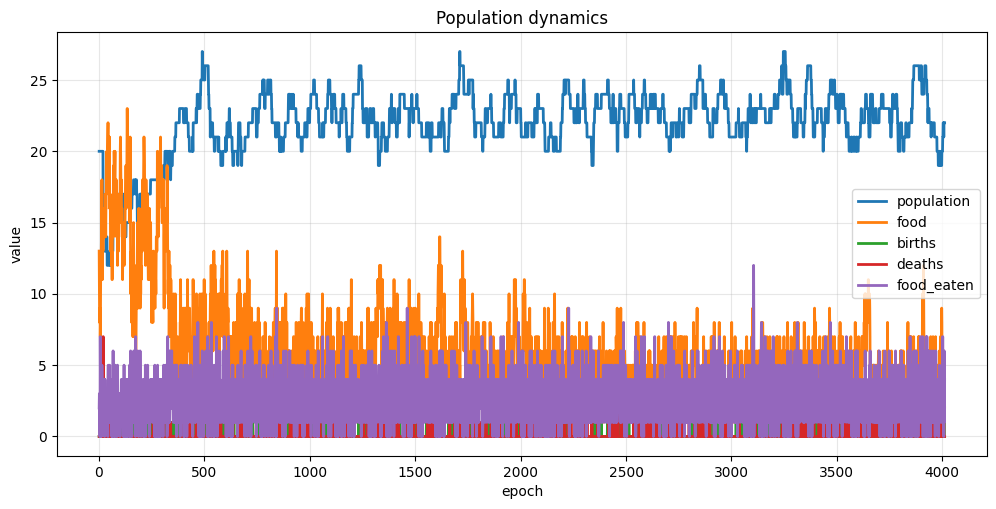

In [23]:
plot_columns(
    "Population dynamics",
    ["population", "food", "births", "deaths", "food_eaten"],
    normalize=False,
)

## Plot 2: Average Traits

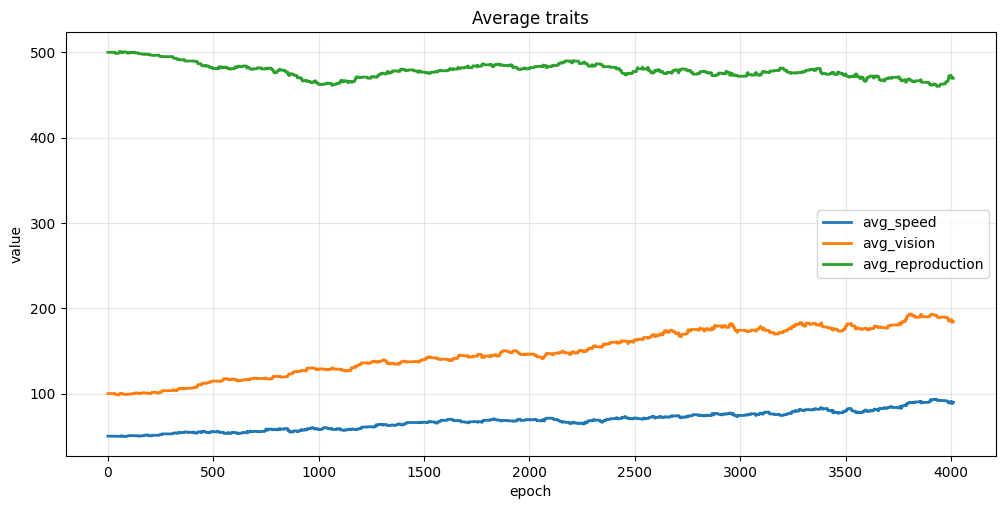

In [24]:
plot_columns(
    "Average traits",
    ["avg_speed", "avg_vision", "avg_reproduction"],
    normalize=False,
)

## Plot 3: Age And Generation

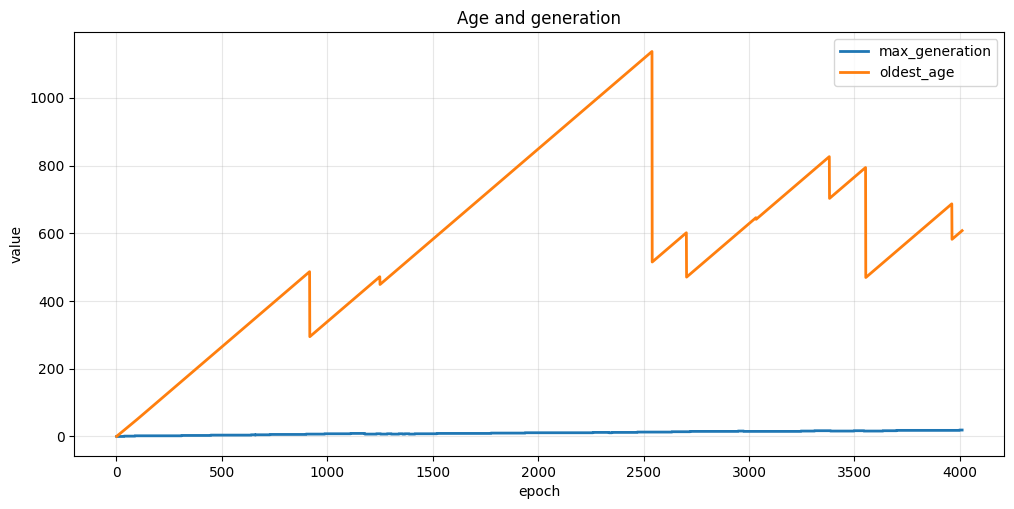

In [25]:
plot_columns(
    "Age and generation",
    ["max_generation", "oldest_age"],
    normalize=False,
)